In [22]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import xgboost as xgb

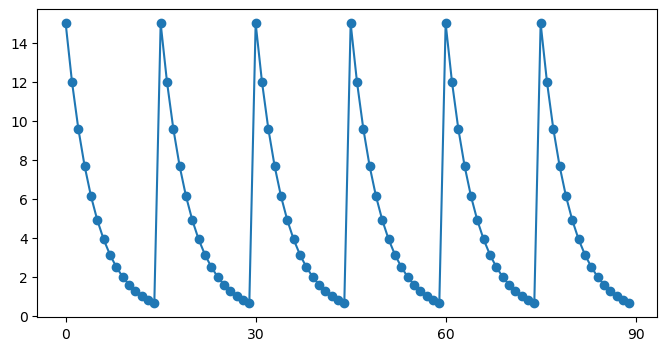

In [23]:
total_steps = 5000000
base_reward = 15.0
decay_rate = 0.8
reward_period = 15 

rewards_in_period = []
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(0,90),rewards_in_period[:90],marker = 'o')
plt.xticks([0,30,60,90])


def reward_simulate_2d(state, t,rewards_in_period):
    state = np.asarray(state, dtype=int)
    phase = t % 30
    if np.array_equal(state, np.array([1,1])) and phase < 15:
        return float(rewards_in_period[t])
    if np.array_equal(state, np.array([5,5])) and phase >= 15:
        return float(rewards_in_period[t])
    return 0.0

def step_at_bounds(state, action, size=7):
    candidate = state + action
    # If candidate goes out of bounds, stay; else move.
    if (candidate < 0).any() or (candidate >= size).any():
        return state.copy()
    return candidate


def simulate_data_raw(rewards_in_period, session_duration = 10000,tdim=50, n_sessions=10,seed  = 515):
    """
    Simulate training and testing data with rewards from a given environment.


    Returns:
    - actions, state, ireward, times: np.ndarrays
    """

    np.random.seed(seed)
    actions, states, irewards,times = [], [], [], []
    # state_initial = int(np.random.choice(np.arange(7)))
    state_initial = [1,1]
    for episode in range(n_sessions):
        t = 0
        episode_data = []
        state = state_initial
        for _ in range(session_duration):
            ireward = reward_simulate_2d(state, t, rewards_in_period)
            # print(len(state))
            state_vec = np.array([state]).reshape(1,len(state))  # shape (1, state_dim)
            time_emb = time_embedding_np(t+1, tdim=tdim).reshape(1,tdim)
            # print(state_vec.shape,time_emb.shape)
            features = np.hstack([state_vec, time_emb])
            ACTIONS = np.array([[0,1],[0,-1],[-1,0],[1,0],[0,0]], dtype=int)
            idx = np.random.randint(len(ACTIONS))
            action = ACTIONS[idx] # up,down, left right
            next_state = step_at_bounds(state, action, size=7)
            episode_data.append((action,features,ireward))
            state = next_state
            t += 1
        for i, (action, features, ireward) in enumerate(episode_data):
            actions.append(action)
            states.append(features)
            irewards.append(ireward)
            times.append(i)

    return (
        np.array(actions),
        np.array(states),
        np.array(irewards),
        np.array(times),
    )

In [24]:
ACTIONS = np.array([[0,1],[0,-1],[-1,0],[1,0],[0,0]], dtype=int)
def _in_bounds(pos, size):
    return 0 <= pos[0] < size and 0 <= pos[1] < size

def get_candidates_2d(state, t, size=7):
    sx, sy = (int(state[0]), int(state[1]))
    curr_state = np.array([sx, sy], dtype=int)
    cands = []
    for d in ACTIONS:
        next_state = curr_state + d
        if _in_bounds(next_state, size):
            cands.append((int(next_state[0]), int(next_state[1])))
        else:
            cands.append((sx, sy))
    seen, uniq = set(), []
    for s in cands:
        if s not in seen:
            seen.add(s)
            uniq.append(s)
    return uniq

def enumerate_paths_2d(x0, t_initial=0, t_prime=20, size=7):
    x0 = (int(x0[0]), int(x0[1]))
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates_2d(curr, t, size=size):
                new_paths.append(path + [nxt])
        paths = new_paths

    cols = [f"t={t_initial+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [52]:
def train_model(X, Y, rf=None, sample_weight = None):
    """Train or continue training the XGBRegressor."""
    if rf is None:
        # rf = xgb.XGBRegressor(
        #     objective="reg:squarederror",
        #     tree_method="exact",
        #     n_jobs=-1,
        #     learning_rate=0.05, max_depth=10,
        #     subsample=1, colsample_bytree=0.8,
        #     n_estimators=2000, eval_metric="rmse"
        # )
        rf = RandomForestRegressor(n_estimators=1000)
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    else:
        if sample_weight is None:
            rf.estimators_ = rf.estimators_[100:]
            rf_new = RandomForestRegressor(n_estimators=100)
            rf_new.fit(X, Y)
            rf.estimators_.extend(rf_new.estimators_)
            # booster = rf.get_booster()
            # sliced = booster[200:]
            # rf_new = xgb.XGBRegressor(
            #     objective="reg:squarederror",
            #     tree_method="exact",
            #     n_jobs=-1,
            #     learning_rate=0.05, max_depth=10,
            #     subsample=1, colsample_bytree=0.8,
            #     n_estimators=2000, eval_metric="rmse")
            # rf_new.fit(X, Y, xgb_model=sliced)
            # rf.fit(X,Y)


        else:
            # rf.estimators_ = rf.estimators_[200:]
            # rf_new = RandomForestRegressor(n_estimators=200)
            # rf_new.fit(X, Y)
            # rf.estimators_.extend(rf_new.estimators_)
            rf.fit(X,Y)
    return rf

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        # if df_paths.shape[1] == 1:
        #     next_state = df_paths
        #     # next_state_x = np.array([next_state[i][0][0] for i in range(df_paths.shape[0])])
        #     # next_state_y = np.array([next_state[i][0][1] for i in range(df_paths.shape[0])])
        #     next_state_x = np.array([next_state[i][0] for i in range(df_paths.shape[0])])
        #     next_state_y = np.array([next_state[i][1] for i in range(df_paths.shape[0])])
        #     # print(next_state_x,next_state_y)
        #     cand_pe_x = position_encoder(next_state_x, type="onehot")
        #     cand_pe_y = position_encoder(next_state_y, type="onehot")
        # else:
        next_state = df_paths.iloc[:,i]
        next_state_x = np.array([next_state[i][0] for i in range(df_paths.shape[0])])
        next_state_y = np.array([next_state[i][1] for i in range(df_paths.shape[0])])
        cand_pe_x = position_encoder(next_state_x, type="onehot")
        cand_pe_y = position_encoder(next_state_y, type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe_x.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
        preds[:, i] = rf.predict(features)
    return preds

def choose_next_state(rf_action, rf_value, current_state, t_now, t_prime_action, t_prime_value, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths_2d(x0=current_state, t_initial=t_now, t_prime=t_prime_action)
    # print(df_paths.shape)
    # df_paths_value = np.asarray(df_paths.iloc[:,-1]).reshape(-1,1)
    df_paths_value = df_paths.iloc[:, [-1]]
    # print(df_paths,df_paths_value)
    preds_action = predict_paths(rf_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(rf_value, df_paths_value, t_now+t_prime_action ,t_prime_value)
    rewards_matrix = preds_action[:, 1:]
    # print(preds_value.shape)
    rewards_matrix = np.hstack([rewards_matrix,preds_value])
    discounts = gamma ** np.arange(0, t_prime_action+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    
    best_idx = np.argmax(total_disc)
    # print(df_paths)
    return df_paths.iloc[best_idx, 1:], df_paths, rewards_matrix

def run_inference(rf_action, rf_value, start_state, T_p, t_prime_action, t_prime_value, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(50):
        next_state, df_paths, preds = choose_next_state(rf_action, rf_value, current_state, T_p + delta_t, t_prime_action, t_prime_value, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate_2d(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 50, gamma,normalization=True)

    # optimal path benchmark
    # path, ireward_opt = path_opt(future_states[0], T_p, 100)
    # preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma,normalization=True)
    # pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    # plotting
    # plt.plot(np.arange(T_p+1, T_p+101), future_states[1:], label="learned")
    # plt.plot(np.arange(T_p,   T_p+101), path, label="optimal")
    # plt.legend()
    # plt.show()

    return  np.sum(preward).item() / 50


In [53]:
T = 3000
gamma = 0.9
t_prime_action = 9
t_batch = 1
t_prime_value = 0
DELTA_T = 100
PREGRETS = []
for rep in range(1):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 50000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    state_posencode_oh_x = position_encoder(states[:,0,0], type="onehot")
    state_posencode_oh_y = position_encoder(states[:,0,1], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh_y,state_posencode_oh_x,states[:,0,2:]])

    X_train = new_state_oh[:T,:]
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)
    Y_train_value = prewards
    rf_value = train_model(X_train, Y_train_value, None)

    PREGRET = []
    # T+=15
    current_state = states[T,0,:2]
    futre_states_2d = [current_state]
    print(current_state)
    for delta_t in range(1,DELTA_T+1):
        t_init = T+(delta_t-1)*t_batch
        next_states, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, t_init, t_prime_action, t_prime_value, gamma)
        NEXT_FEATURES = []
        NEXT_REWARD = []
        for actor_i in range(t_batch):
            next_time = t_init+actor_i+1
            next_state = next_states[actor_i]
            print(next_time,next_state)
            next_state_x = np.array([next_state[0]])
            next_state_y = np.array([next_state[1]])
            cand_pe_x = position_encoder(next_state_x, type="onehot")
            cand_pe_y = position_encoder(next_state_y, type="onehot")
            time_emb = time_embedding_np(next_time+1, tdim=50).reshape(1,-1)
            next_features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
            next_reward = reward_simulate_2d(next_state, next_time, rewards_in_period)

            current_state = next_state
            futre_states_2d.append(current_state)

            NEXT_FEATURES.append(next_features)
            NEXT_REWARD.append(next_reward)
        # print(t_init+t_batch,future_states)
        NEXT_FEATURES_arr = np.vstack([NEXT_FEATURES])[:,0,:]
        NEXT_REWARD_arr = np.vstack([NEXT_REWARD])
        # PolicyIteration
        X_train = np.vstack([X_train, NEXT_FEATURES_arr])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), NEXT_REWARD_arr.reshape(-1,1)])

        rf_action = train_model(X_train, Y_train_action, rf_action)
        print(t_init, "rf_action train done")
        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = t_init+t_batch,normalization = False)
        # is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        # print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value,rf_value)
        print(t_init,"rf_value train done")
        
        # T_p = delta_t + T
        # start_state = current_state
        # preward_val = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        # print(f"rep {rep}, T_train {T_p}, pregret={preward_val:.4f}")
        # PREGRET.append(preward_val)
        
    
    



[2. 3.]


KeyboardInterrupt: 

In [41]:
pattern = [[1,1],[1,1],[1,1],[1,1],[1,1],[1,1],[1,1],[1,1],[1,2],[1,3],[1,4],[1,5],[2,5],[3,5],[4,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[5,5],[4,5],[3,5],[2,5],[1,5],[1,4],[1,3],[1,2]]
future_states_opt = np.array(pattern*(session_duration // len(pattern)))

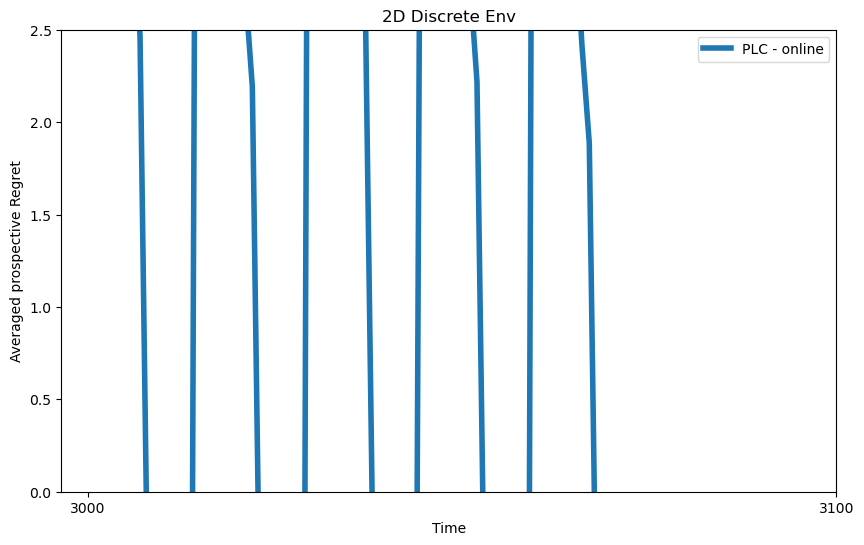

In [49]:
prewards = []
gamma = 0.5
delta_future = 30
for i in range(len(futre_states_2d)-delta_future):
    irewards = []
    ireward_opt = []
    for j in range(i,i+delta_future):
        state = np.array(futre_states_2d[j])
        t = i
        ireward_opt.append(reward_simulate_2d(future_states_opt[t], t,rewards_in_period))
        irewards.append(reward_simulate_2d(state, t,rewards_in_period))
    preward = make_weighted_target(irewards, gamma,T = delta_future,normalization = True)
    preward_opt = make_weighted_target(ireward_opt, gamma,T = delta_future,normalization = True)
    prewards.append((np.sum(preward_opt) - np.sum(preward))/delta_future)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(3000,3071,1),prewards,lw = 4,label = 'PLC - online')
plt.yticks([0,0.5,1,1.5,2,2.5,3])
plt.ylim([0,2.5])
plt.xticks([3000,3100])
plt.xlabel('Time')
plt.ylabel('Averaged prospective Regret')
plt.title('2D Discrete Env')
plt.legend()

In [50]:
prewards

[np.float64(11.623046718614184),
 np.float64(9.396874937537355),
 np.float64(7.674999975161629),
 np.float64(6.391999990299346),
 np.float64(4.982948829471331),
 np.float64(3.941157198265219),
 np.float64(3.124293438826766),
 np.float64(2.4686026957663643),
 np.float64(-0.5015530468381552),
 np.float64(-0.46905984905300063),
 np.float64(-0.4292164705235689),
 np.float64(-0.3174280318448108),
 np.float64(-0.24665518845334636),
 np.float64(-0.19477337627080585),
 np.float64(-0.15485742779479642),
 np.float64(9.999511083897795),
 np.float64(8.399218496431352),
 np.float64(7.038749898869999),
 np.float64(5.474686001244013),
 np.float64(4.334446483603896),
 np.float64(3.4496867928590946),
 np.float64(2.7498813674649125),
 np.float64(2.1911066905978154),
 np.float64(-0.6911824115896882),
 np.float64(-0.5700750202169614),
 np.float64(-0.4830438288843312),
 np.float64(-0.42944073343464534),
 np.float64(-0.37793468071070385),
 np.float64(-0.3298444344293182),
 np.float64(-0.28586927610146146),


In [ ]:
T = 3000
gamma = 0.9
t_prime_action = 9
t_batch = 5
t_prime_value = 0
DELTA_T = 200
PREGRETS = []
for rep in range(1):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 50000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    state_posencode_oh_x = position_encoder(states[:,0,0], type="onehot")
    state_posencode_oh_y = position_encoder(states[:,0,1], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh_y,state_posencode_oh_x,states[:,0,2:]])

    X_train = new_state_oh[:T,:]
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)
    Y_train_value = prewards
    rf_value = train_model(X_train, Y_train_value)

    PREGRET = []
    # T+=15
    current_state = states[T,0,:2]
    futre_states_2d = [current_state]
    print(current_state)
    for delta_t in range(1,DELTA_T+1):
        t_init = T+(delta_t-1)*t_batch
        next_states, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, t_init, t_prime_action, t_prime_value, gamma)
        NEXT_FEATURES = []
        NEXT_REWARD = []
        for actor_i in range(t_batch):
            next_time = t_init+actor_i+1
            next_state = next_states[actor_i]
            print(next_time,next_state)
            next_state_x = np.array([next_state[0]])
            next_state_y = np.array([next_state[1]])
            cand_pe_x = position_encoder(next_state_x, type="onehot")
            cand_pe_y = position_encoder(next_state_y, type="onehot")
            time_emb = time_embedding_np(next_time+1, tdim=50).reshape(1,-1)
            next_features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
            next_reward = reward_simulate_2d(next_state, next_time, rewards_in_period)

            current_state = next_state
            futre_states_2d.append(current_state)

            NEXT_FEATURES.append(next_features)
            NEXT_REWARD.append(next_reward)
        # print(t_init+t_batch,future_states)
        NEXT_FEATURES_arr = np.vstack([NEXT_FEATURES])[:,0,:]
        NEXT_REWARD_arr = np.vstack([NEXT_REWARD])
        # PolicyIteration
        X_train = np.vstack([X_train, NEXT_FEATURES_arr])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), NEXT_REWARD_arr.reshape(-1,1)])

        rf_action = train_model(X_train, Y_train_action, rf_action)
        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = t_init+t_batch,normalization = False)
        # is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        # print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value)
        
        
        # T_p = delta_t + T
        # start_state = current_state
        # preward_val = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        # print(f"rep {rep}, T_train {T_p}, pregret={preward_val:.4f}")
        # PREGRET.append(preward_val)
        
    
    

